<h1> Geometric Operations and Other Mathematical Tools</h1>


Estimated time needed: **40** minutes


<h2>Objectives</h2>


In the first part of the lab, you will apply geometric transformations to an image. This allows you to perform different operations like reshape translation, i.e. to shift, reshape and rotate the image. In the second part of the lab, you will learn how to apply some basic array and matrix operations to the image. 


<ul>
    <li><a href='#PT'> Geometric Operations  </a>
        <ul>
            <li>Scaling</li>
            <li>Translation</li>
            <li>Rotation</li>   
          </ul>
        <li><a href='#PT'>  Mathematical Operations   </a>
        <ul>
            <li>Array Operations  </li>
            <li>Matix Operations n</li> 
          </ul>


</ul>


----


Download the image for the lab:


In [5]:
!curl "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png -O lenna.png"
!curl "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png -O baboon.png"
!curl "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png -O barbara.png"

curl: (3) URL rejected: Malformed input to a URL function
curl: (3) URL rejected: Malformed input to a URL function
curl: (3) URL rejected: Malformed input to a URL function


We will be using the following imported functions in this lab:


In [35]:
import matplotlib.pyplot as plt   # Vẽ hình ảnh, biểu đồ
from PIL import Image             # Đọc và xử lý ảnh
import numpy as np                # Xử lý mảng số (ảnh dưới dạng ma trận)

First, let's define a helper function to plot two images side-by-side. You will not need to understand this code this moment, but this function will be used repeatedly in this tutorial to showcase the results. 


In [36]:
def plot_image(image_1, image_2, title_1="Original", title_2="New Image"):  # Hàm hiển thị 2 ảnh để so sánh
    plt.figure(figsize=(10,10))   # Tạo cửa sổ hiển thị kích thước 10x10 inch
    plt.subplot(1, 2, 1)          # Chia bố cục 1 hàng, 2 cột, chọn vị trí thứ 1
    plt.imshow(image_1, cmap="gray")  # Hiển thị ảnh thứ nhất (thang xám)
    plt.title(title_1)            # Đặt tiêu đề cho ảnh thứ nhất
    plt.subplot(1, 2, 2)          # Chọn vị trí thứ 2 trong bố cục
    plt.imshow(image_2, cmap="gray")  # Hiển thị ảnh thứ hai
    plt.title(title_2)            # Đặt tiêu đề cho ảnh thứ hai
    plt.show()                    # Hiển thị toàn bộ hình 

#  Geometric Transformations


 Geometric transformations allow you to perform different operations like translation, i.e. to shift, reshape and rotate the image.


We can resize an image using the method  <code>resize()</code> of <code>PIL</code> images, which takes the resized image's <code>width</code> and <code>height</code> as paramters. 

Consider the following image:


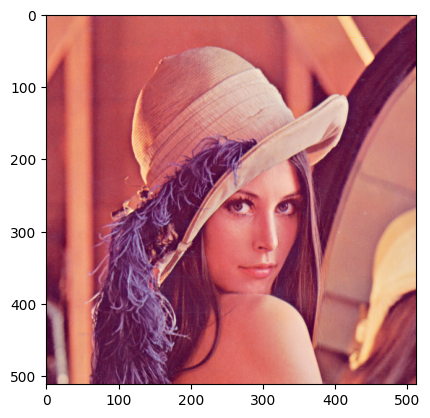

In [37]:
image = Image.open("lenna.png")   # Đọc ảnh từ file
plt.imshow(image)                 # Hiển thị ảnh
plt.show()                        # Hiển thị kết quả


We can scale the horizontal axis by two and leave the vertical axis as is:


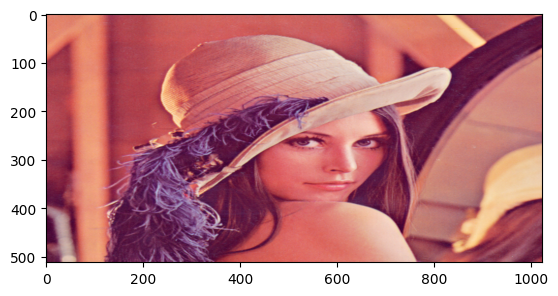

In [38]:
width, height = image.size            # Lấy kích thước ảnh gốc
new_width = 2 * width                 # Gấp đôi chiều rộng
new_height = height                   # Giữ nguyên chiều cao
new_image = image.resize((new_width, new_height))  # Resize ảnh
plt.imshow(new_image)                 # Hiển thị ảnh mới
plt.show()                            # Hiển thị kết quả

In the same manner, we can scale the vertical axis by two:


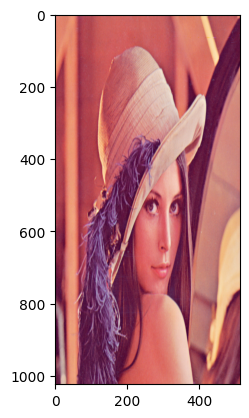

In [ ]:
new_width = width                     # Giữ nguyên chiều rộng ban đầu
new_hight = 2 * height                # Tăng chiều cao lên gấp đôi
new_image = image.resize((new_width, new_hight))  # Thay đổi kích thước ảnh
plt.imshow(new_image)                 # Hiển thị ảnh sau khi resize
plt.show()                            # Hiển thị kết quả


We can double both the width and the height of the image:


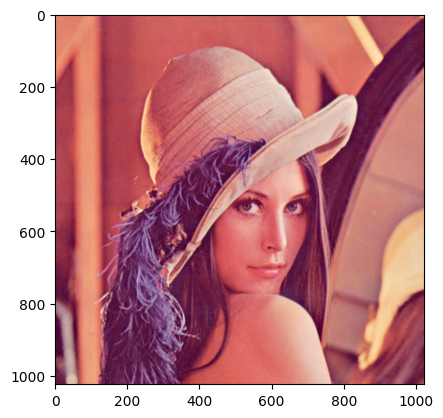

In [41]:
new_width = 2 * width                 # Tăng chiều rộng lên gấp đôi
new_hight = 2 * height                # Tăng chiều cao lên gấp đôi (nên viết là new_height)
new_image = image.resize((new_width, new_hight))  # Thay đổi kích thước ảnh theo kích thước mới
plt.imshow(new_image)                 # Hiển thị ảnh sau khi phóng to
plt.show()                            # Hiển thị kết quả


We can also shrink the image's width and height both by 1/2:


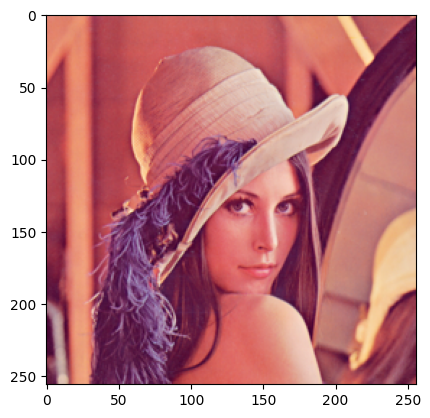

In [42]:
new_width = width // 2                # Giảm chiều rộng xuống còn một nửa
new_hight = height // 2               # Giảm chiều cao xuống còn một nửa 
new_image = image.resize((new_width, new_hight))  # Thay đổi kích thước ảnh 
plt.imshow(new_image)                 # Hiển thị ảnh sau khi thu nhỏ
plt.show()                           # Hiển thị kết quả

## Rotation 


We can rotate an image by angle $\theta$, using the method `rotate`.


We can rotate our toy image by 45 degrees:


In [43]:
theta = 45                         # Góc xoay ảnh 
new_image = image.rotate(theta)    # Xoay ảnh một góc 45 độ 


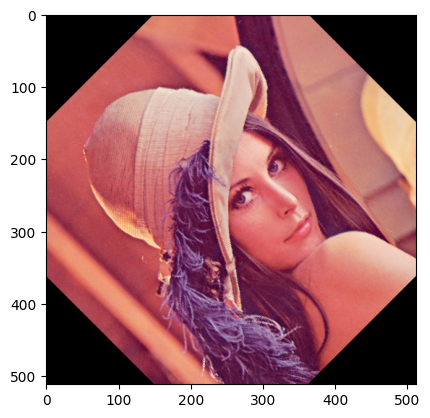

In [44]:
plt.imshow(new_image)               # Hiển thị ảnh sau khi xoay
plt.show()                          # Hiển thị kết quả

# Mathematical Operations 


## Array Operations 


We can perform array operations on an image; Using Python broadcasting, we can add a constant to each pixel's intensity value. 

Before doing that, we must first we convert the PIL image to a numpy array.


In [45]:
image = np.array(image)   # Chuyển ảnh từ định dạng PIL Image sang mảng NumPy 

We can then add the constant to the image array:


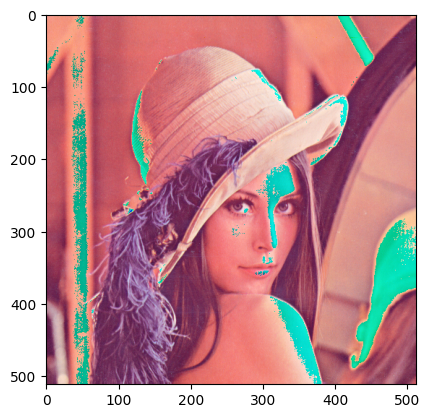

In [46]:
new_image = image + 20      # Tăng giá trị cường độ của mỗi pixel thêm 20 
plt.imshow(new_image)       # Hiển thị ảnh sau khi tăng độ sáng
plt.show()                  # Hiển thị kết quả

We can also multiply every pixel's intensity value by a constant value.


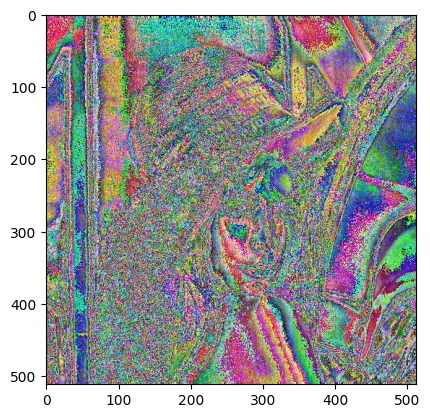

In [47]:
new_image = 10 * image        # Nhân mỗi giá trị pixel với 10 
plt.imshow(new_image)         # Hiển thị ảnh sau khi biến đổi
plt.show()                    # Hiển thị kết quả

We can add the elements of two arrays of equal shape. In this example, we generate an array of random noises with the same shape and data type as our image.


In [48]:
Noise = np.random.normal(0, 20, (height, width, 3)).astype(np.uint8)  
# Tạo nhiễu Gaussian với:
# mean = 0, độ lệch chuẩn = 20
# kích thước cho ảnh màu
# chuyển sang kiểu uint8
Noise.shape   # Kiểm tra kích thước của mảng nhiễu

(512, 512, 3)

We add the generated noise to the image and plot the result. We see the values that have corrupted the image:


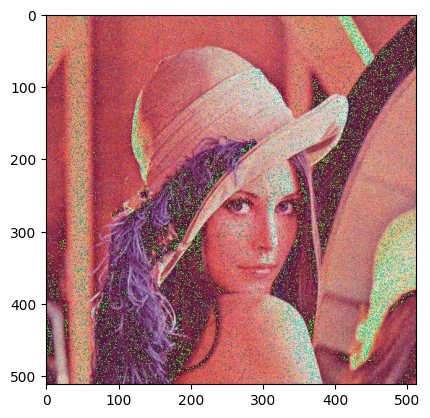

In [49]:
new_image = image + Noise      # Cộng nhiễu Gaussian vào ảnh gốc 

plt.imshow(new_image)          # Hiển thị ảnh sau khi thêm nhiễu
plt.show()                     # Hiển thị kết quả


At the same time, we can multiply the elements of two arrays of equal shape. We can multiply the random image and the Lenna image and plot the result. 


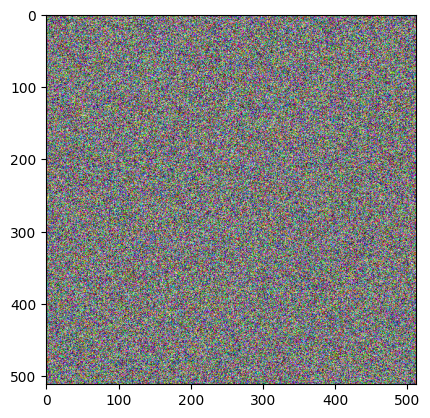

In [50]:
new_image = image * Noise      # Nhân từng pixel của ảnh với nhiễu 

plt.imshow(new_image)          # Hiển thị ảnh sau khi thêm nhiễu nhân
plt.show()                     # Hiển thị kết quả

## Matrix Operations 


Grayscale images are matrices. Consider the following grayscale image:


In [51]:
im_gray = Image.open("barbara.png")    # Mở file ảnh

Even though the image is gray, it has three channels; we can convert it to a one-channel image.


In [52]:
from PIL import ImageOps          # Import thư viện ImageOps để xử lý ảnh

In [53]:
im_gray = ImageOps.grayscale(im_gray)       # Chuyển ảnh màu sang ảnh xám

We can convert the PIL image to a numpy array:


In [54]:
im_gray = np.array(im_gray )         # Chuyển ảnh từ PIL sang mảng NumPy

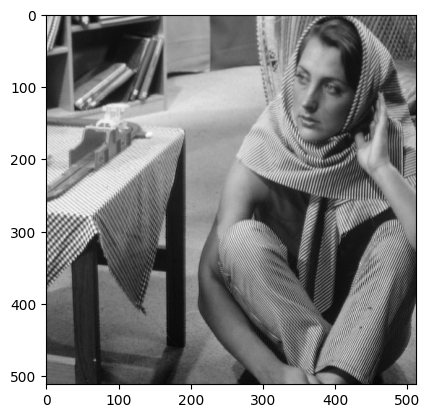

In [55]:
plt.imshow(im_gray,cmap='gray')         # Hiển thị ảnh xám
plt.show()                              # Hiển thị kết quả

We can apply algorithms designed for matrices.  We can use  Singular Value Decomposition, decomposing our image matrix into  a product of three matrices.


In [56]:
U, s, V = np.linalg.svd(im_gray , full_matrices=True)     # Thực hiện phân rã SVD của ảnh xám


We see <code>s</code> is not rectangular:


In [57]:
s.shape      # Xem kích thước của vector singular values 

(512,)

We can convert  <code>s</code> to a diagonal matrix <code>S</code>:


In [58]:
S = np.zeros((im_gray.shape[0], im_gray.shape[1]))  # Tạo ma trận S toàn số 0 với cùng kích thước ảnh 

S[:im_gray.shape[0], :im_gray.shape[0]] = np.diag(s)  # Đặt các singular values vào đường chéo chính của ma trận S

We can plot the matrix U and V:


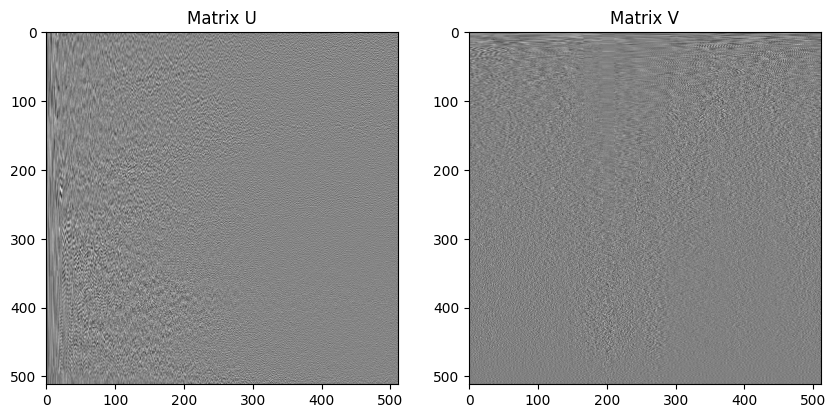

In [59]:
plot_image(U, V, title_1="Matrix U", title_2="Matrix V")   # Hiển thị ma trận U và V thu được từ phân rã SVD

We see most of the elements in S are zero:


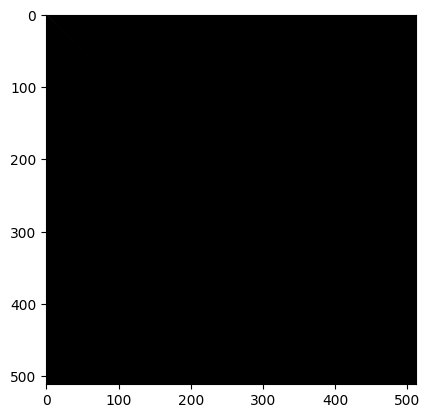

In [60]:
plt.imshow(S, cmap='gray')    # Hiển thị ma trận Sigma (S) dưới dạng ảnh xám
plt.show()                    # Hiển thị kết quả

We can find the matrix product of all the  matrices. First, we can perform matrix multiplication on S and U and assign it to `B` and plot the results: 


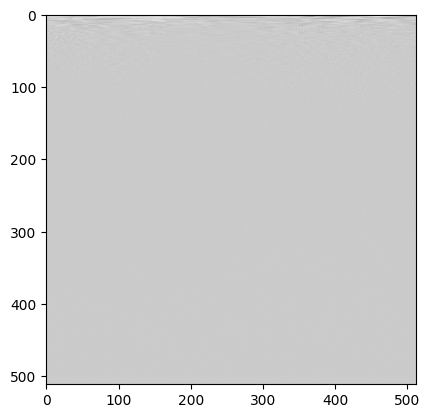

In [62]:
B = S.dot(V)                 # Nhân ma trận Sigma (S) với ma trận V (B = S × V)
plt.imshow(B, cmap='gray')   # Hiển thị kết quả dưới dạng ảnh xám
plt.show()                   # Hiển thị kết quả

We can find the matrix product of `U`, `S`, and `B`. We see it's the entire image:


In [63]:
A = U.dot(B)     # Nhân ma trận U với B để tái tạo lại ảnh (A = U × S × V)

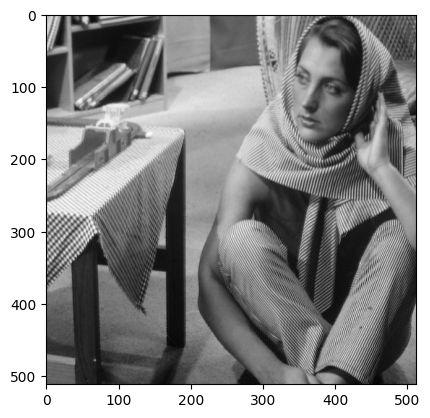

In [64]:
plt.imshow(A,cmap='gray')         # Hiển thị ảnh tái tạo dưới dạng ảnh xám
plt.show()                        # Hiển thị kết quả

It turns out that many elements are redundant. We can eliminate some rows and columns of S and V and approximate the image by finding the product:


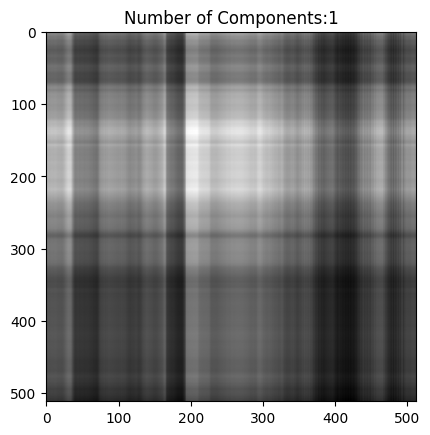

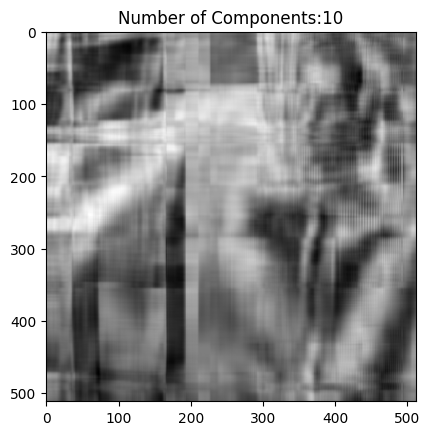

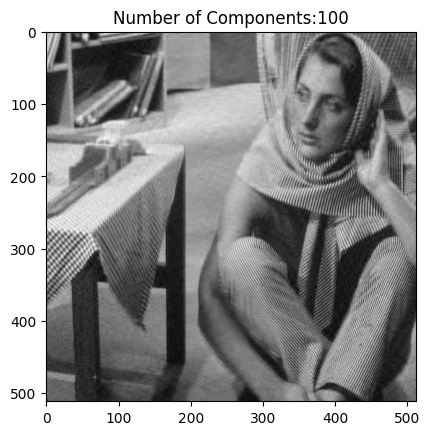

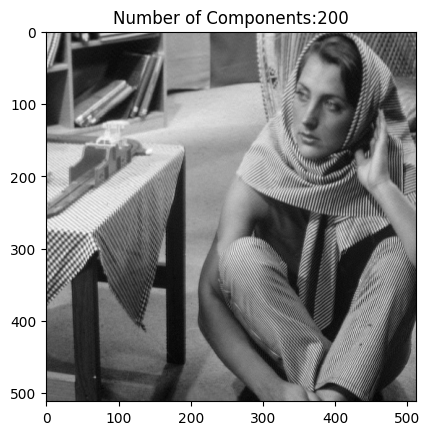

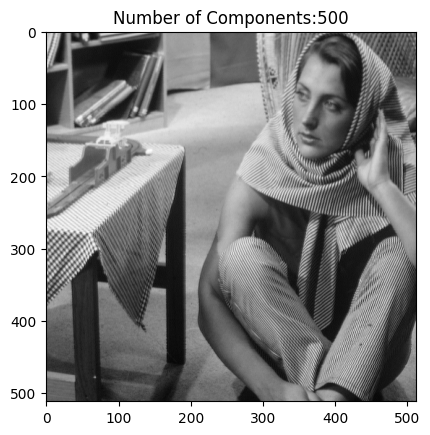

In [65]:
for n_component in [1, 10, 100, 200, 500]:   # Lặp qua các giá trị số thành phần SVD cần giữ lại
    S_new = S[:, :n_component]               # Giữ lại n_component cột đầu của ma trận Sigma
    V_new = V[:n_component, :]               # Giữ lại n_component hàng đầu của ma trận V
    A = U.dot(S_new.dot(V_new))              # Tái tạo ảnh gần đúng: A ≈ U × S_new × V_new
    plt.imshow(A, cmap='gray')               # Hiển thị ảnh tái tạo
    plt.title("Number of Components:" + str(n_component))  # Tiêu đề hiển thị số thành phần
    plt.show()                               # Hiển thị kết quả


We see we only need 100 to 200 Components to represent the image.


# References 


[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.


<!--<h2>Change Log</h2>-->


<!--<table>
    <tr>
        <th>Date (YYYY-MM-DD)</th>
        <th>Version</th>
        <th>Changed By</th>
        <th>Change Description</th>
    </tr>
    <tr>
        <td>2020-07-20</td>
        <td>0.2</td>
        <td>Azim</td>
        <td>Modified Multiple Areas</td>
    </tr>
    <tr>
        <td>2020-07-17</td>
        <td>0.1</td>
        <td>Azim</td>
        <td>Created Lab Template</td>
    </tr>
</table>
-->


<h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
